# Scanpy Tutorial Notebook

This notebook is a classroom-friendly walkthrough for the BIOM440 course project. It uses Scanpy's built-in `pbmc68k_reduced` dataset so the demo stays focused on interpretation rather than file wrangling.

Core goals:
- verify the Scanpy environment
- load an `AnnData` object
- inspect how metadata and embeddings are stored
- generate a UMAP, marker-gene dotplot, and summary violin plot
- connect the plots back to biological interpretation


## 1. Installation check


The following code checks the installation and imports all necessary softwares.
The version printout confirms the package imported correctly.


In [3]:
# This section is for set-up only. Please do not edit this code!

from pathlib import Path

import scanpy as sc

project_dir = Path.cwd()
figure_dir = project_dir / "tutorial_figures"
figure_dir.mkdir(exist_ok=True)

sc.settings.figdir = figure_dir
sc.settings.set_figure_params(dpi=120, facecolor="white")
sc.logging.print_header()

print(f"Scanpy version: {sc.__version__}")
print(f"Figures will be saved to: {figure_dir.resolve()}")

Scanpy version: 1.11.5
Figures will be saved to: C:\Users\errin\ClassFiles\BIOM440\Team_See\Aimee Messing Around\tutorial_figures


C:\Users\errin\AppData\Local\Temp\ipykernel_17156\3247915912.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"Scanpy version: {sc.__version__}")


## 2. Load a built-in example dataset

This tutorial currently uses `pbmc68k_reduced`, a packaged peripheral blood mononuclear cell dataset that already includes useful annotations and embeddings for demonstration.

If you want to swap in a different built-in example, here are some common Scanpy options:

- `sc.datasets.pbmc68k_reduced()` - subsampled and processed 68k PBMC dataset
- `sc.datasets.pbmc3k()` - 3k PBMCs from 10x Genomics
- `sc.datasets.pbmc3k_processed()` - processed 3k PBMC dataset
- `sc.datasets.paul15()` - myeloid progenitor development dataset
- `sc.datasets.krumsiek11()` - simulated myeloid progenitor dataset
- `sc.datasets.moignard15()` - hematopoiesis in early mouse embryos
- `sc.datasets.blobs()` - synthetic Gaussian blobs dataset
- `sc.datasets.toggleswitch()` - simulated toggle-switch dataset
- `sc.datasets.visium_sge()` - spatial Visium gene expression dataset

To choose a different one, change the dataset-loading line in the next code cell.


In [4]:
# This loads the dataset into an Anndata object, 
# which is a reduced version of the original dataset for faster loading and testing. 
# The original dataset contains around 68,000 cells, 
# but this reduced version contains fewer cells for quicker analysis.

adata = sc.datasets.pbmc68k_reduced() 

## 3. What an AnnData object stores

`AnnData` is the core data structure in Scanpy.

- `adata.X` stores the main expression matrix
- `adata.obs` stores cell-level metadata
- `adata.var` stores gene-level metadata
- `adata.obsm` stores low-dimensional coordinates like PCA or UMAP
- `adata.uns` stores unstructured analysis results

That organization is one reason Scanpy is so practical for reproducible analysis. Using these commands, we can tell important information about the dataset, such as the number of cells and genes, as well as the structure of the data.

After running the following cell, take a moment to look at the printed AnnData object and understand what it contains.
- `obs` are the observations, which in this case are the cells. Var are the variables, which are the genes.
- `obsm` are the multi-dimensional annotations, which can contain things like dimensionality reduction coordinates.
- `varm` are the multi-dimensional annotations for the variables, which can contain things like gene sets or pathways.
- `Obsp` are the pairwise annotations between observations and variables, which can contain things like gene expression values.

In [ ]:
print(adata)
print(f"Cells: {adata.n_obs}")
print(f"Genes: {adata.n_vars}")

print("obs columns:", list(adata.obs.columns))
print("var columns:", list(adata.var.columns))
print("obsm keys:", list(adata.obsm.keys()))


display(adata.obs.head())


AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
Cells: 700
Genes: 765
obs columns: ['bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain']
var columns: ['n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable']
obsm keys: ['X_pca', 'X_umap']


,bulk_labels,n_genes,percent_mito,n_counts,S_score,G2M_score,phase,louvain
index,,,,,,,,
AAAGCCTGGCTAAC-1,CD14+ Monocyte,1003,0.023856,2557.0,-0.119160,-0.816889,G1,1
AAATTCGATGCACA-1,Dendritic,1080,0.027458,2695.0,0.067026,-0.889498,S,1
AACACGTGGTCTTT-1,CD56+ NK,1228,0.016819,3389.0,-0.147977,-0.941749,G1,3
AAGTGCACGTGCTA-1,CD4+/CD25 T Reg,1007,0.011797,2204.0,0.065216,1.469291,G2M,9
ACACGAACGGAGTG-1,Dendritic,1178,0.017277,3878.0,-0.122974,-0.868185,G1,2


### Extra AnnData exploration

A few helpful checks can make the object feel less mysterious:

- `adata.shape` tells you the matrix size as cells x genes
- `adata.obs_names` and `adata.var_names` store row and column labels
- `adata.obsm` holds multi-dimensional arrays such as UMAP coordinates
- `adata[:, genes]` or `adata[cells, :]` lets you slice the object like a matrix

These small examples are useful if you want to click around and see how the pieces fit together.


In [6]:
print(f"adata shape: {adata.shape} (cells x genes)")
print("First 5 cell names:", list(adata.obs_names[:5]))
print("First 5 gene names:", list(adata.var_names[:5]))
print("Has raw matrix:", adata.raw is not None)
print("layers keys:", list(adata.layers.keys()))
print("obsm keys:", list(adata.obsm.keys()))
print("uns keys:", list(adata.uns.keys())[:10])


adata shape: (700, 765) (cells x genes)
First 5 cell names: ['AAAGCCTGGCTAAC-1', 'AAATTCGATGCACA-1', 'AACACGTGGTCTTT-1', 'AAGTGCACGTGCTA-1', 'ACACGAACGGAGTG-1']
First 5 gene names: ['HES4', 'TNFRSF4', 'SSU72', 'PARK7', 'RBP7']
Has raw matrix: True
layers keys: []
obsm keys: ['X_pca', 'X_umap']
uns keys: ['bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups']


In [7]:
print("Cell metadata preview:")
display(adata.obs.head())

print("Gene metadata preview:")
display(adata.var.head())


Cell metadata preview:


,bulk_labels,n_genes,percent_mito,n_counts,S_score,G2M_score,phase,louvain
index,,,,,,,,
AAAGCCTGGCTAAC-1,CD14+ Monocyte,1003,0.023856,2557.0,-0.119160,-0.816889,G1,1
AAATTCGATGCACA-1,Dendritic,1080,0.027458,2695.0,0.067026,-0.889498,S,1
AACACGTGGTCTTT-1,CD56+ NK,1228,0.016819,3389.0,-0.147977,-0.941749,G1,3
AAGTGCACGTGCTA-1,CD4+/CD25 T Reg,1007,0.011797,2204.0,0.065216,1.469291,G2M,9
ACACGAACGGAGTG-1,Dendritic,1178,0.017277,3878.0,-0.122974,-0.868185,G1,2


Gene metadata preview:


,n_counts,means,dispersions,dispersions_norm,highly_variable
index,,,,,
HES4,1153.387451,0.592365,2.028047,2.771764,True
TNFRSF4,304.358154,0.193332,1.760724,2.746426,True
SSU72,2530.272705,1.019981,1.208284,-0.631160,False
PARK7,7451.664062,1.828078,1.288261,-0.544716,False
RBP7,272.811035,0.174943,1.842789,3.192285,True


In [8]:
if "X_umap" in adata.obsm:
    print("First 5 UMAP coordinates:")
    display(adata.obsm["X_umap"][:5])
else:
    print("This dataset does not include X_umap in adata.obsm.")


First 5 UMAP coordinates:


array([[-1.99186255,  8.57641706],
       [-3.24869194,  7.99994913],
       [-3.59310303, -2.22675898],
       [-7.80369074, -3.96445355],
       [ 5.0282945 , -1.76706602]])

### Try subsetting the AnnData object

One of the nicest things about `AnnData` is that you can slice it and keep the metadata aligned.
The example below makes a tiny 5-cell x 5-gene subset so you can inspect it more easily.


In [9]:
small_adata = adata[:5, :5].copy()

print(small_adata)
display(small_adata.to_df())


AnnData object with n_obs × n_vars = 5 × 5
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


index,HES4,TNFRSF4,SSU72,PARK7,RBP7
index,,,,,
AAAGCCTGGCTAAC-1,-0.326,-0.191,-0.728,-0.301,3.386
AAATTCGATGCACA-1,1.171,-0.191,0.795,-1.200,-0.174
AACACGTGGTCTTT-1,-0.326,-0.191,0.483,-1.200,-0.174
AAGTGCACGTGCTA-1,-0.326,-0.191,1.134,-0.157,-0.174
ACACGAACGGAGTG-1,-0.326,-0.191,-0.728,-0.607,-0.174


## 4. UMAP overview

UMAP projects cells into two dimensions while trying to preserve local neighborhood structure. Here we color the embedding by:

- `bulk_labels`: broad immune-cell identity labels
- `n_genes`: the number of genes detected per cell

This makes it easy to show both biological grouping and a simple quality-related metric.


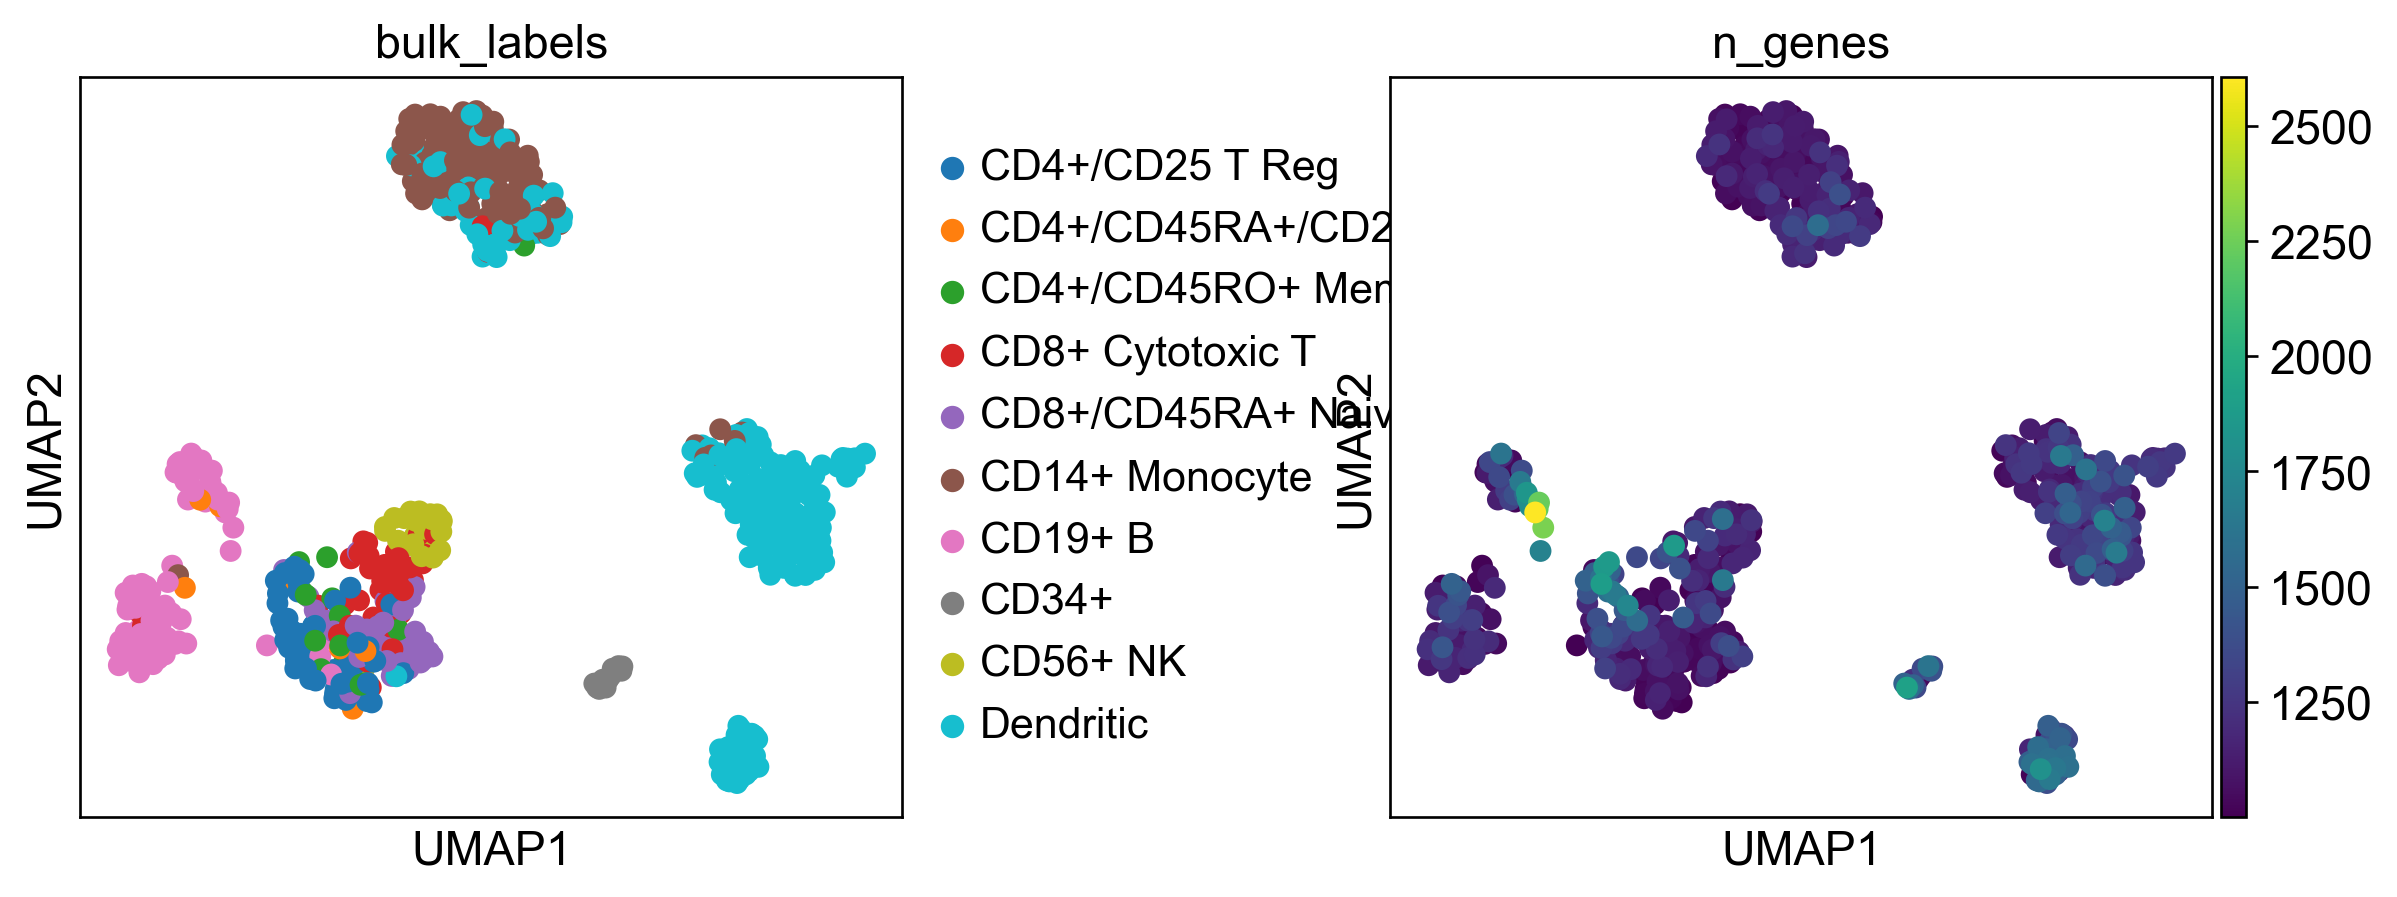

In [10]:
sc.pl.umap(
    adata,
    color=["bulk_labels", "n_genes"],
    wspace=0.45,
    save="_pbmc68k_overview.png",
    show=True,
)


## 5. Marker-gene dotplot

The dotplot helps us map clusters back to biology. Dot size reflects the fraction of cells expressing a gene, while color reflects relative expression level.

These markers are commonly useful in PBMC datasets:

- `CD3D` for T cells
- `MS4A1` for B cells
- `NKG7` and `GNLY` for NK cells
- `LYZ` and `FCGR3A` for monocyte-related populations


Markers used: ['CST3', 'NKG7', 'MS4A1', 'CD3D', 'LYZ', 'FCGR3A', 'GNLY']


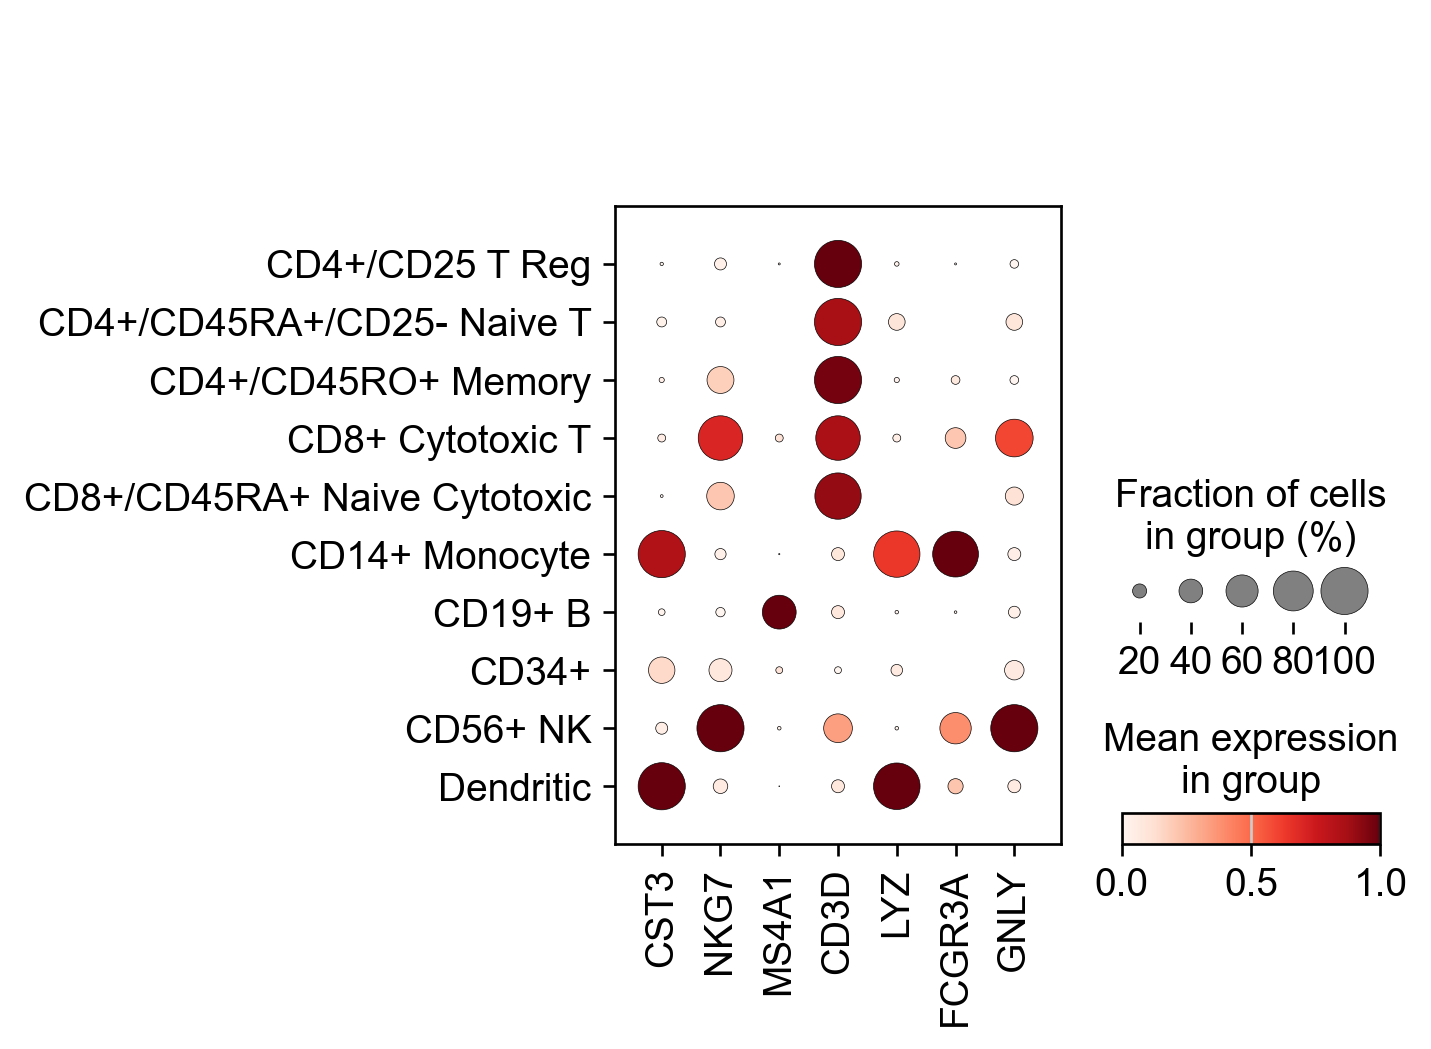

In [11]:
candidate_markers = ["CST3", "NKG7", "MS4A1", "CD3D", "LYZ", "PPBP", "FCGR3A", "GNLY"]
markers = [gene for gene in candidate_markers if gene in adata.var_names]

print("Markers used:", markers)

sc.pl.dotplot(
    adata,
    var_names=markers,
    groupby="bulk_labels",
    standard_scale="var",
    save="_pbmc68k_marker_dotplot.png",
    show=True,
)


## 6. Summary violin plot

Violin plots are helpful for comparing quality-control style variables across groups. They are a nice reminder that Scanpy is not only for clustering and embeddings; it is also useful for diagnosing technical variation.


Available summary variables: ['n_genes', 'percent_mito', 'n_counts']


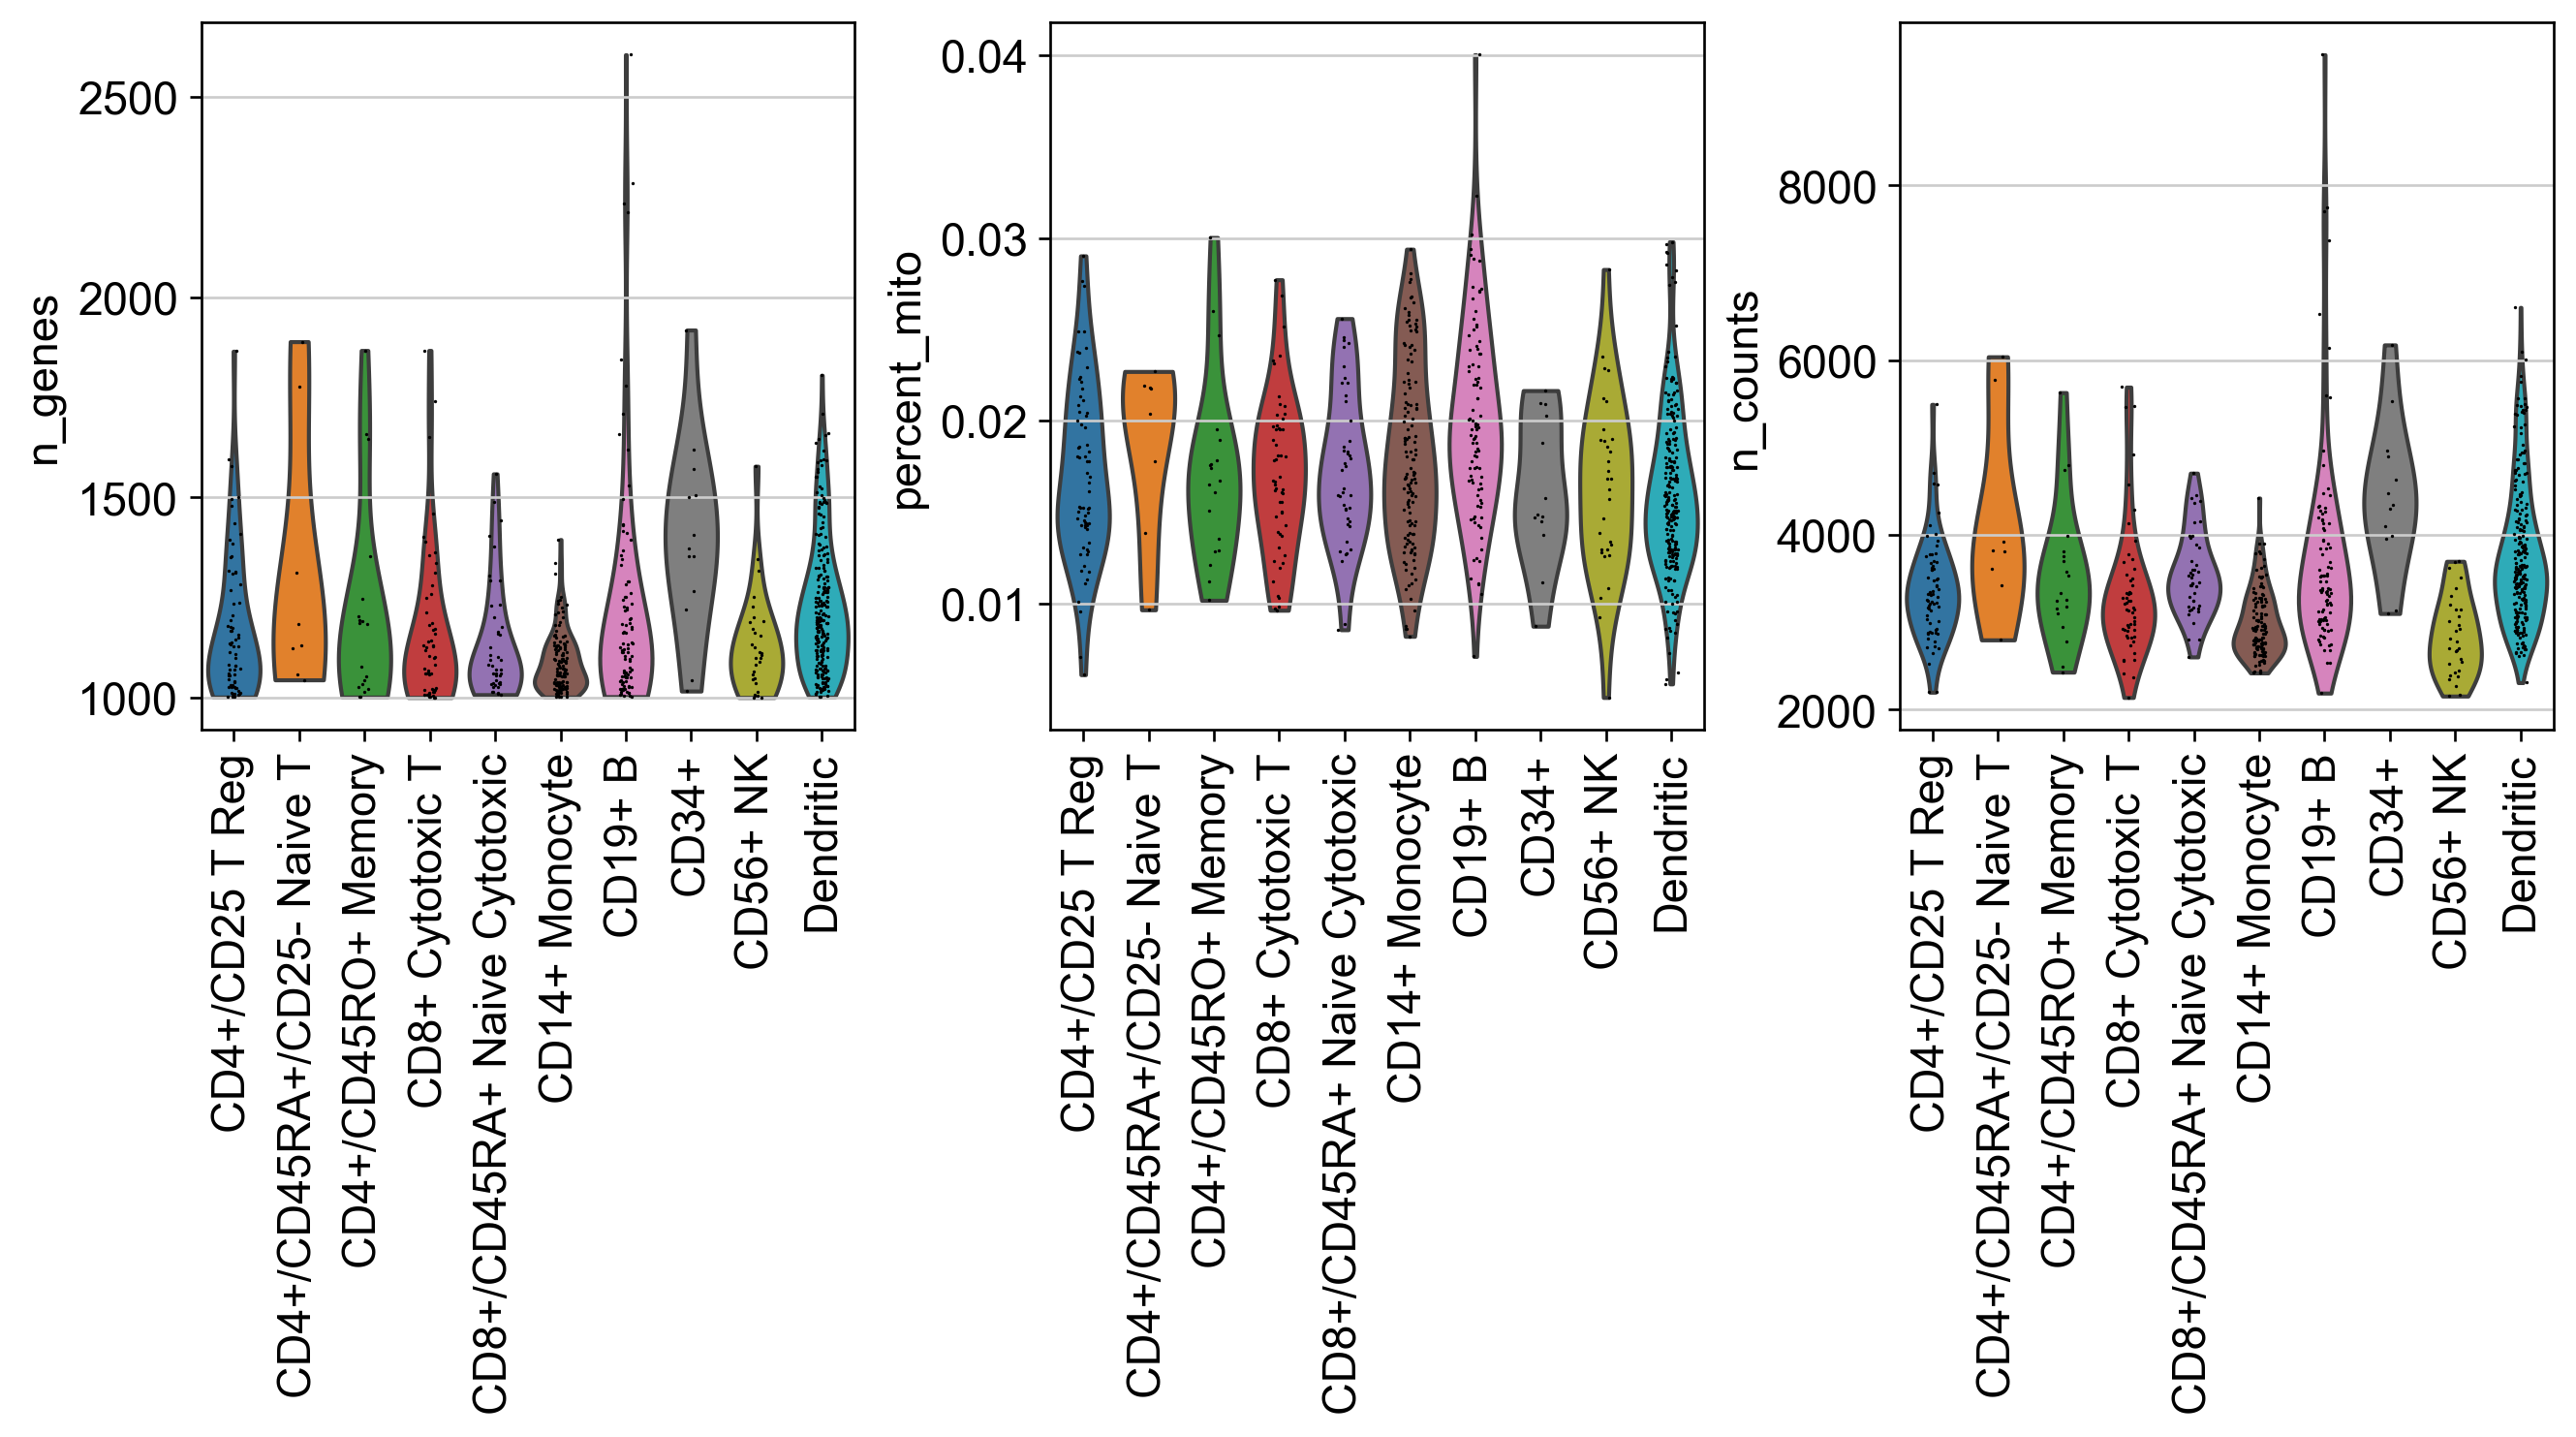

In [12]:
available_qc = [column for column in ["n_genes", "percent_mito", "n_counts"] if column in adata.obs.columns]
print("Available summary variables:", available_qc)

if available_qc:
    sc.pl.violin(
        adata,
        keys=available_qc,
        groupby="bulk_labels",
        rotation=90,
        save="_pbmc68k_summary_violin.png",
        show=True,
    )
else:
    print("No QC summary columns were available in this dataset.")


## 7. Interpretation notes for the presentation

A concise way to explain the results live:

- UMAP shows that cells with similar expression profiles cluster together.
- Marker-gene expression helps assign biological meaning to those clusters.
- Violin plots show how summary variables differ across groups and can support quality-control discussion.

That gives classmates the full path from expression matrix to biologically interpretable cell populations.


In [13]:
print("Saved figure files:")
for path in sorted(figure_dir.glob("*")):
    print(path.name)


Saved figure files:
dotplot__pbmc68k_marker_dotplot.png
umap_pbmc68k_overview.png
violin_pbmc68k_summary_violin.png
